In [2]:
# TODO 1: import yfinance, numpy, matplotlib
# TODO 2: download SPY from 2020-01-01, auto_adjust=True, store in df
# TODO 3: print the first 5 rows and the shape
# TODO 4: make a column "ret" = daily % change of Close
# TODO 5: make a column "vol20" = 20-day rolling std of ret, annualized
# TODO 6: plot Close and vol20 as two stacked charts
# TODO 7: histogram of ret with 50 bins
# TODO 8: print the date with the highest vol20
# TODO 9: print the worst single-day return and its date
# TODO 10: Markdown cell with 3 things you noticed

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib as plt

df = yf.download("SPY", start="2020-01-01", end="2025-01-01", auto_adjust=True)
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2020-01-02,296.125214,296.143462,293.992262,294.912905,59151200
2020-01-03,293.882935,295.004113,292.688847,292.743535,77709700
2020-01-06,295.004181,295.086214,292.014370,292.132872,55653900
2020-01-07,294.174652,294.912981,293.727989,294.438973,40496400
2020-01-08,295.742493,296.954801,294.119989,294.366089,68296000


<class 'pandas.Series'>


Price,Close,High,Low,Open,Volume,ret,vol20
Ticker,SPY,SPY,SPY,SPY,SPY,,
Date,,,,,,,
2020-01-02,296.125214,296.143462,293.992262,294.912905,59151200,NaN,NaN
2020-01-03,293.882935,295.004113,292.688847,292.743535,77709700,-0.007572,NaN
2020-01-06,295.004181,295.086214,292.014370,292.132872,55653900,0.003815,NaN
2020-01-07,294.174652,294.912981,293.727989,294.438973,40496400,-0.002812,NaN
2020-01-08,295.742493,296.954801,294.119989,294.366089,68296000,0.005330,NaN
...,...,...,...,...,...,...,...
2024-12-19,574.302002,581.063131,574.057034,579.456130,85919500,-0.000307,0.127048
2024-12-20,581.199951,585.722501,571.132258,571.977828,125716700,0.012011,0.133055


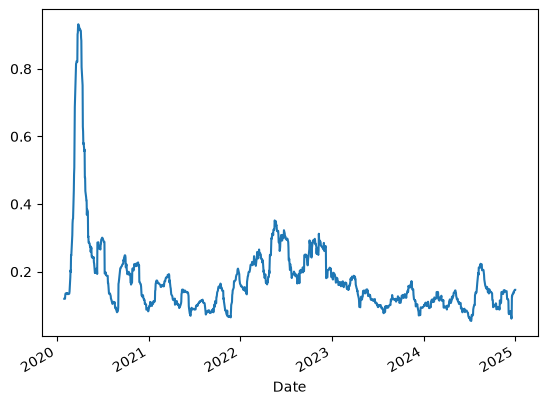

In [8]:
close = df['Close'].squeeze()
print(type(close))

df['ret'] = close.pct_change()
df['vol20'] = df['ret'].rolling(20).std() * np.sqrt(252)
df['vol20'].plot()

df.head(-3)

df is a pandas dataframe
in close = df['Close'].squeeze() i took a column and then squeezed it into one column so that it becomes a pandas.Series type

.pct_change computes the fractional change from the immediate row and the previous. or the daily percent change in price as a decimal.

.rolling(n) takes a window of n and then performs the operation on the n rows that you chain after. For example, .rolling(n).std()

multiplying by np.sqrt(252) normalizes the daily std we calced over 20 days into an annual std. if we want months we can use sqrt12 instead.

